$$f(x) = \frac{p}{2} ||Ax - b||^2 + \sum_{i=1}^m \log ( 2 \cosh (u_i^\top (x - a))),$$

$$a \in \R^n, b \in \R^m, A \in \R^{m \times n}, u_i \in \R^n, p \ge 0, m=\frac{n}{5}.$$

In [44]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [7]:
def f_value(x, A, b, a, U, p):
    term1 = (p/2) * np.linalg.norm(A @ x - b)**2
    z = U @ (x - a)
    term2 = np.sum(np.log(2*np.cosh(z)))
    return term1 + term2

In [8]:
def gradient(x, A, b, a, U, p):
    g1 = p * A.T @ (A @ x - b)
    z = U @ (x - a)
    g2 = U.T @ np.tanh(z)

    return g1 + g2

In [9]:
def estimate_L(A, U, p):
    LA = np.linalg.norm(A, 2)**2
    LU = np.linalg.norm(U, 2)**2
    return p * LA + LU

Реализуем метод линейного каплинга с моментумом из прошлой лабораторной

$$ y = x - h \cdot \nabla f(x) $$
$$ z_{k+1} = z_k + \beta (z_k - z{k-1}) - \gamma \cdot \nabla f(x) $$
$$ x_{k+1} = \tau \cdot z_{k+1} + (1 - \tau) \cdot y $$

In [10]:
def project(x, q, eta):
    if q @ x <= eta:
        return x

    return x - ((q @ x - eta) / (q @ q)) * q

In [69]:
def linear_coupling_momentum(
    x0, A, b, a, U, p, q, eta,
    eps=1e-2,
    max_iter=10000,
    tau=0.3,
    beta=0.7,   # momentum
):
    L = estimate_L(A, U, p)

    h = 1.0 / L
    gamma = 1.0 / L  

    x = x0.copy()
    z = x0.copy()
    z_prev = x0.copy()

    history = []
    for k in range(max_iter):
        g = gradient(x, A, b, a, U, p)

        if np.linalg.norm(g) < eps:
            break

        y = x - h * g
        z_new = z + beta * (z - z_prev) - gamma * g
        x_new = tau * z_new + (1 - tau) * y
        x_new = project(x_new, q, eta)  # projection in halfspace

        z_prev = z
        z = z_new
        x = x_new

        # if np.linalg.norm(x_new - x) < eps:
        #     print("сходимость по малому шагу")
        #     break

        history.append(f_value(x, A, b, a, U, p))

    return x, history

In [70]:
def generate_problem(n, rng):
    if not rng:
        rng = np.random

    m = max(1, n // 5)
    A = rng.randn(m, n)
    b = rng.randn(m)
    a = rng.randn(n)
    U = rng.randn(m, n)
    p = rng.rand() + 0.1   # always should be > 0
    q = rng.randn(n)
    eta = abs(rng.randn()) + 0.5  # чтобы x=0 точно был допустим

    return A, b, a, U, p, q, eta

In [71]:
def generate_start_points(n, num_points=100):
    return [np.random.randn(n) for _ in range(num_points)]

In [72]:
def run_experiment(
    method,
    eps=1e-2,
    max_iter=10000,
    num_starts=100,
    seed=42
):
    rng = np.random.RandomState(seed)

    results = {}

    for n in tqdm(range(10, 101, 10), desc=f"Running {method.__name__}"):
        problem = generate_problem(n, rng)
        A, b, a, U, p, q, eta = problem

        starts = generate_start_points(n, num_starts)

        best_result = None
        best_value = np.inf

        runs_data = []
        for x0 in starts:
            start_time = time.perf_counter()

            out = method(
                x0, A, b, a, U, p, q, eta,
                eps=eps,
                max_iter=max_iter,
            )

            end_time = time.perf_counter()

            if isinstance(out, tuple):
                x_sol = out[0]
                history = out[1] if len(out) > 1 else []
            else:
                x_sol = out
                history = []

            f_val = f_value(x_sol, A, b, a, U, p)
            iters = len(history) if history else None
            runtime = end_time - start_time

            run_info = {
                "x": x_sol,
                "f_value": f_val,
                "iterations": iters,
                "time": runtime,
                "history": history,
            }

            runs_data.append(run_info)

            if f_val < best_value:
                best_value = f_val
                best_result = run_info

        results[n] = {
            "best": best_result,
            "all_runs": runs_data,
        }

    return results

In [73]:
lc_mom_results = run_experiment(linear_coupling_momentum)

Running linear_coupling_momentum: 100%|██████████| 10/10 [00:01<00:00,  6.08it/s]


In [74]:
def plot_convergence(results, n_values=None):
    plt.figure()

    if n_values is None:
        n_values = sorted(results.keys())

    for n in n_values:
        history = results[n]["best"]["history"]

        if history:
            plt.plot(history, label=f"n={n}")

    plt.xlabel("Iteration")
    plt.ylabel("f(x)")
    plt.title("Convergence of f(x_k)")
    plt.legend()
    plt.grid()

    plt.show()

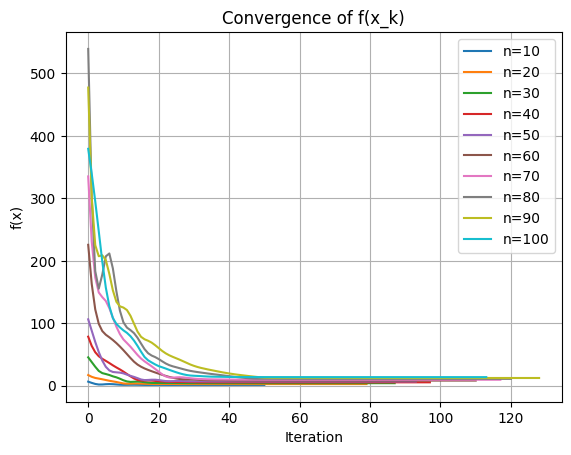

In [75]:
plot_convergence(lc_mom_results)

Уменьшение параметров $\tau$ и $\beta$ приводит к снижению осцилляций и более стабильной сходимости, особенно в присутствии проекционного шага, который нарушает инерционную динамику метода. \
При большом $\beta$ метод “перелетает” минимум \
А при уменьшении $\tau$ больше веса у градиентного шага, чем у momentum, поэтому снижение получается более контролируемым

In [76]:
def plot_scaling(results):
    ns = sorted(results.keys())

    times = []
    iters = []

    for n in ns:
        best = results[n]["best"]
        times.append(best["time"])
        iters.append(best["iterations"])

    # время
    plt.figure()
    plt.plot(ns, times, marker='o')
    plt.xlabel("n")
    plt.ylabel("Time (sec)")
    plt.title("Time vs Dimension")
    plt.grid()
    plt.show()

    # итерации
    plt.figure()
    plt.plot(ns, iters, marker='o')
    plt.xlabel("n")
    plt.ylabel("Iterations")
    plt.title("Iterations vs Dimension")
    plt.grid()
    plt.show()

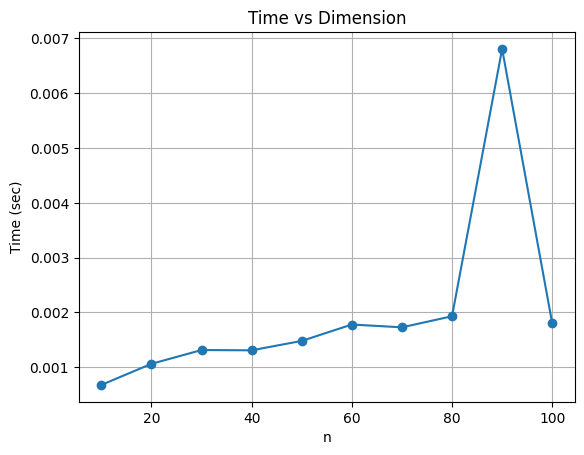

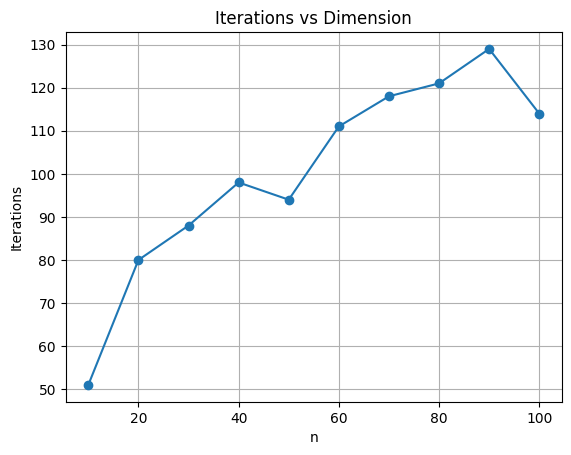

In [77]:
plot_scaling(lc_mom_results)